# Imports

In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
import os
import glob
import graphical_sampling as gs
import pandas as pd
import numpy as np
import itertools
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities

# Loading and Determining Population

In [43]:
DATA_DIR = "populations"
csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    name = os.path.splitext(os.path.basename(fp))[0]
    data = np.loadtxt(fp, delimiter=",", skiprows=1)
    coords = data[:, :2]
    probs  = data[:, -1]

    coord_name, prob_name, *rest = name.split("_")
    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict[coord_name] = probs_dict.get(coord_name, {})
    probs_dict[coord_name][prob_name] = probs

print(coords_dict.keys())
print(probs_dict.keys())
print(probs_dict['random'].keys())

dict_keys(['cluster', 'AggregatedPop1027', 'random', 'meuse', 'grid', 'RegularPop1000', 'swiss'])
dict_keys(['cluster', 'AggregatedPop1027', 'random', 'meuse', 'grid', 'RegularPop1000', 'swiss'])
dict_keys(['equal', 'unequal'])


In [122]:
coords = np.loadtxt("populations/AggregatedPop1027_2d.csv", delimiter=",", skiprows=0)
# coords = np.loadtxt("populations/RegularPop1000_2d.csv", delimiter=",", skiprows=0)
print(len(coords))
rng = gs.random.rng()
n = 20
probs = rng.equal_probabilities(n, coords.shape[0])
pop = gs.Population(coords, probs)


1000


In [123]:
print(probs.sum())

20.0


In [ ]:
# n = 20, spiral spiral Regular
# density	0.006099	0.030789
# moran	-0.254578	0.043766
# local_balance	0.129771	0.040084
# voronoi	0.076617	0.039016

# n = 50, spiral spiral Regular
# density	0.004681	0.013391
# moran	-0.356249	0.027877
# local_balance	0.070798	0.015639
# voronoi	0.060610	0.022326

# n = 100, spiral spiral Regular
# density	0.003941	0.010907
# moran	-0.422802	0.028637
# local_balance	0.048174	0.005673
# voronoi	0.061820	0.010714

# n = 200, spiral spiral Regular
# density	0.001457	0.005671
# moran	-0.468132	0.051531
# local_balance	0.036911	0.002876
# voronoi	0.084660	0.013132



# Aggregated

# n = 20, spiral spiral Aggregated
# density	0.070551	0.059996
# moran	-0.272021	0.037297
# local_balance	0.117540	0.021086
# voronoi	0.088505	0.031076

# N = 1000
# density	0.047492	0.073194
# moran	-0.264656	0.036106
# local_balance	0.130582	0.016019
# voronoi	0.103656	0.027035


# n = 50, spiral spiral Aggregated
# density    	0.021019	0.030379
# moran	       -0.383385	0.033951
# local_balance	0.085965	0.009068
# voronoi	    0.115908	0.021655

# N = 1000
# density	    0.023742	0.029862
# moran	       -0.382071	0.037122
# local_balance	0.081808	0.009369
# voronoi   	0.107387	0.022718



# n = 100, spiral spiral Aggregated
# density	0.015215	0.014299
# moran	-0.471527	0.037610
# local_balance	0.064090	0.006586
# voronoi	0.134618	0.024624

# tested!   N = 1000
# density	0.012937	0.020156
# moran	-0.450826	0.037109
# local_balance	0.064394	0.005713
# voronoi	0.139970	0.025929



# n = 200, spiral spiral Aggregated
# density	0.002533	0.007840
# moran	-0.481015	0.032362
# local_balance	0.047896	0.003533
# voronoi	0.155401	0.019599

# Building Initial Designs

In [125]:
orders = [
    # "lexico-yx",
    # "lexico-xy",
    # "random",
    # "angle_0",
    # "distance_0",
    # "projection",
    # "center",
    "spiral",
    # "max",
    # "snake",
    # "hilbert",
]
n_zones_sweep = [(2, 2)]
# n_zones_cluster = [4]
combinations = list(itertools.product(['sweep'], n_zones_sweep, orders, orders))# + list(itertools.product(['cluster'], n_zones_cluster, orders, orders))

In [126]:
initial_designs = []
num_trials = 1
for zone_builder, n_zones, units_order, zones_order in tqdm(combinations, desc="Generating initial designs", total=len(combinations), unit="orders"):
    best = None
    best_score = np.inf
    for _ in range(num_trials):
        ks = gs.sampling.KMeansSampler(
            population=pop,
            n=n,
            n_zones=n_zones,
            zone_builder=zone_builder,
            units_order=units_order,
            zones_order=zones_order,
            split_size=0.001
        )
        if ks.expected_moran_score() < best_score:
            best = ks
            best_score = ks.expected_moran_score()
            print(f"New best score: {best_score} for {zone_builder}, {n_zones}, {units_order}, {zones_order}")

    initial_designs.append(gs.NewDesign(best))

Generating initial designs:   0%|          | 0/1 [00:00<?, ?orders/s]

/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/us

New best score: -0.2481497787083889 for sweep, (2, 2), spiral, spiral


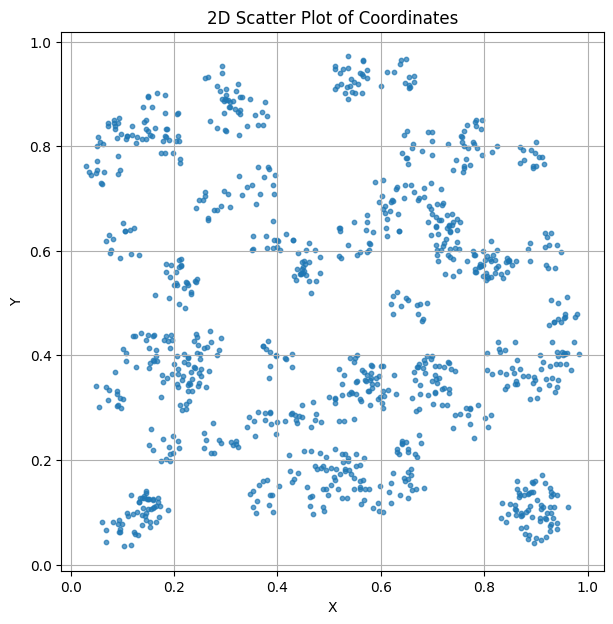

In [128]:
import matplotlib.pyplot as plt

# coords already loaded from your code above

plt.figure(figsize=(7, 7))
plt.scatter(coords[:, 0], coords[:, 1], s=10, alpha=0.7)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Scatter Plot of Coordinates")
plt.grid(True)
plt.show()

# Run

In [129]:
moran_criteria = gs.criteria.MoranCriteria()

In [130]:
initial_criteria_value = np.array([moran_criteria(design) for design in initial_designs])
print(initial_criteria_value)
best_design = initial_designs[np.argmin(initial_criteria_value)]
best_criteria_value = np.min(initial_criteria_value)
best_criteria_value
initial_designs[np.argmin(initial_criteria_value)].kmeans.score_summary_df()


[-0.24814978]


,expected,std
measure,,
density,0.035874,0.059761
moran,-0.248150,0.059758
local_balance,0.132967,0.022560
voronoi,0.106992,0.038718


In [131]:
astar = gs.search.AStar(
    initial_designs,
    moran_criteria
)

best initial criteria value -0.2481497787083889


In [136]:
astar = gs.search.AStar(
    [astar.best_design],
    moran_criteria
)

best initial criteria value -0.2632102610231585


In [138]:
astar.run(
    max_iterations = 100,
    num_new_nodes = 20,
    max_open_set_size = 1000,

    n_clusters_to_change_order_zone = 0,
    n_changes_in_order_of_zones = 0,

    n_clusters_to_change_order_units = 1,
    n_zones_to_change_order_units = 1,
    n_changes_in_order_of_units = 1,

    n_jobs=-1
)


parent node: -0.2632102610231585


/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/us

child node: -0.2632224225861515

New best criteria value: -0.2632224225861515
child node: -0.263014358466691
child node: -0.2632068242172304
child node: -0.2628417749972199
child node: -0.26329068946259176

New best criteria value: -0.26329068946259176
child node: -0.2631253456556867
child node: -0.26299052939903234
child node: -0.26282518313736397
child node: -0.26308563042126104
child node: -0.2632102610231585
child node: -0.2631748886334168
child node: -0.263426337107498

New best criteria value: -0.263426337107498
child node: -0.26274639260588967
child node: -0.2627748190313018
child node: -0.26325981297640266
child node: -0.26265165226413395
child node: -0.2627133162079223
child node: -0.2627380859885236
child node: -0.2632104894471063

parent node: -0.263426337107498
child node: -0.2620443276953203
child node: -0.2629361339232526
child node: -0.26347421970893425

New best criteria value: -0.26347421970893425
child node: -0.2632231103953403
child node: -0.26312013698026837
child n

KeyboardInterrupt: 

In [139]:
astar.best_design.kmeans.score_summary_df()

,expected,std
measure,,
density,0.047492,0.073194
moran,-0.264656,0.036106
local_balance,0.130582,0.016019
voronoi,0.103656,0.027035


In [140]:

for cluster in astar.best_design.kmeans.clusters:
    cluster_index_share = cluster.get_index_share()
    print(f'\ncluster prob sum: {np.sum(pop.probs[cluster_index_share[:, 0].astype(int)])}')
    for zone in cluster.zones:
        print(f'zone prob sum: {np.sum(zone.prob)}')


cluster prob sum: 1.0
zone prob sum: 0.24999999999999997
zone prob sum: 0.24999999999999992
zone prob sum: 0.24999999999999992
zone prob sum: 0.24999999999999997

cluster prob sum: 1.0
zone prob sum: 0.2499999999999999
zone prob sum: 0.24999999999999997
zone prob sum: 0.24999999999999997
zone prob sum: 0.24999999999999992

cluster prob sum: 1.0
zone prob sum: 0.24999999999999992
zone prob sum: 0.24999999999999992
zone prob sum: 0.24999999999999997
zone prob sum: 0.24999999999999997

cluster prob sum: 1.0
zone prob sum: 0.2499999999999999
zone prob sum: 0.24999999999999997
zone prob sum: 0.24999999999999997
zone prob sum: 0.24999999999999992

cluster prob sum: 1.0
zone prob sum: 0.24999999999999997
zone prob sum: 0.24999999999999992
zone prob sum: 0.24999999999999992
zone prob sum: 0.24999999999999997

cluster prob sum: 1.0
zone prob sum: 0.24999999999999992
zone prob sum: 0.24999999999999992
zone prob sum: 0.24999999999999997
zone prob sum: 0.24999999999999997

cluster prob sum: 1.0
z

In [141]:
astar.best_design.kmeans.all_samples_probs.sum()

np.float64(0.9999999999999998)

In [142]:
astar.best_design.kmeans.all_samples.shape

(90, 20)

In [143]:
np.mean(np.abs(astar.best_design.kmeans.fips - probs))

np.float64(0.0)

In [144]:
astar.best_design.kmeans.fips

array([0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.

In [114]:
np.mean(np.abs(initial_design.kmeans.fips - probs))

NameError: name 'initial_design' is not defined

In [87]:
max(astar.best_design.kmeans.fips)

np.float64(0.2210321329999999)

In [88]:
200/1027

0.19474196689386564

In [29]:
np.sqrt(astar.best_design.kmeans.var_moran_score())

np.float64(0.051920976433342605)

In [76]:
astar.best_design.kmeans.moran_scores

array([-0.50854305, -0.54293679, -0.65922451, -0.64147852, -0.57183288,
       -0.58202557, -0.56105458, -0.45920847, -0.5618256 , -0.59335246,
       -0.54823247, -0.589926  , -0.53048317, -0.56353487, -0.54957034,
       -0.55135462, -0.63054903, -0.62841727, -0.59349016, -0.71381491,
       -0.66701377, -0.57776011, -0.55605104, -0.58317301, -0.63929135,
       -0.48359111, -0.61539171, -0.51574499, -0.55439157, -0.58472678,
       -0.71808128, -0.6459911 , -0.52057374, -0.59028964, -0.57343073,
       -0.61691472, -0.70571138, -0.56483565, -0.64364067, -0.60274384,
       -0.62059921, -0.57920348, -0.71291035, -0.54268658, -0.63107332,
       -0.52090799, -0.65304167, -0.68789819, -0.45113366, -0.39102337])

In [67]:
astar.best_design.kmeans.score_summary_df()

,expected,std
measure,,
density,0.166571,0.117680
moran,-0.452472,0.068235
local_balance,0.226800,0.052961
voronoi,0.090396,0.046718


NameError: name 'initial_design' is not defined

In [30]:
def info(kmeans):
    mean = round(float(kmeans.expected_moran_score()), 2)
    moran_scores = astar.best_design.kmeans.moran_scores
    median = round(float(np.median(moran_scores)), 2)
    sd = round(float(np.sqrt(kmeans.var_moran_score())), 2)
    min_ = round(float(np.min(moran_scores)), 2)
    max_ = round(float(np.max(moran_scores)), 2)
    return mean, median, sd, min_, max_

In [31]:
info(astar.best_design.kmeans)

(-0.25, -0.25, 0.05, -0.4, -0.14)

In [23]:
gs.plot(pop, astar.best_design.kmeans.clusters, connect_points=False)

NameError: name 'astar' is not defined